# RETAIL SALES ANALYSIS

# Dataset Loading and Initial Inspection

In [ ]:
import pandas as pd

In [4]:
import os

In [5]:
os.getcwd()

'C:\\Users\\USER'

In [6]:
os.chdir('C:\\Users\\USER\\OneDrive\\Pictures\\oasis intern')

In [7]:
df=pd.read_csv("retail_sales_dataset.csv")

In [8]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [9]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [11]:
df.shape

(1000, 9)

In [12]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [13]:
df.isna()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False


In [14]:
df.isna().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

# Descriptive Statistics

In [ ]:
type(df)

In [16]:
numeric_cols=df.select_dtypes(include='number').columns

In [17]:
df[numeric_cols].mean()

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [18]:
df[numeric_cols].median()

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [19]:
df[numeric_cols].mode().iloc[0]

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

In [20]:
df[numeric_cols].std()

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

# Monthly Sales Trend

In [21]:
import matplotlib.pyplot as plt

In [22]:
df['Date']=pd.to_datetime(df['Date'])

In [23]:
df['Sales']=df['Quantity']*df['Price per Unit']

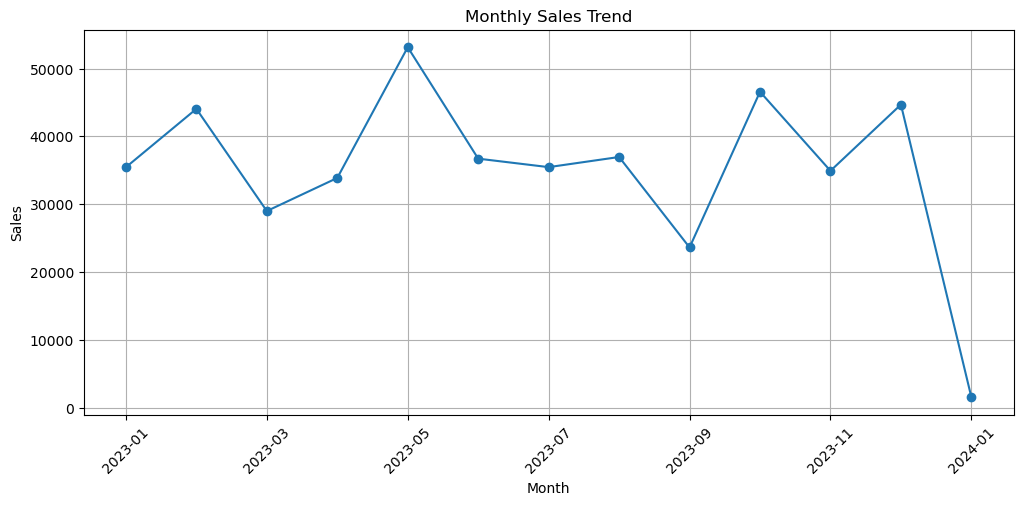

In [24]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.plot(
    kind='line',
    figsize=(12, 5),
    marker='o',
    title='Monthly Sales Trend'
)

plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Quaterly Sales Trend

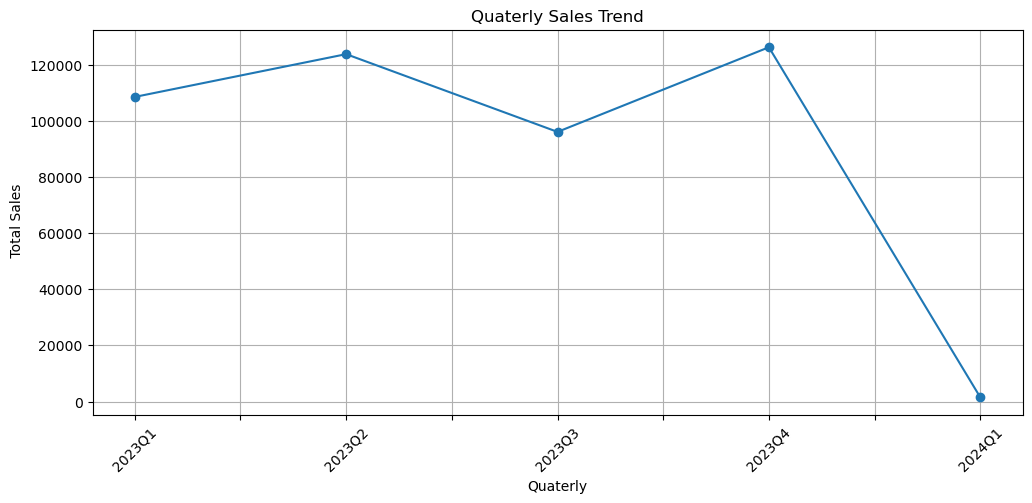

In [64]:
quaterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

quaterly_sales.index = quaterly_sales.index.astype(str)

quaterly_sales.plot(
    kind='line',
    figsize=(12, 5),
    marker='o',
    title='Quaterly Sales Trend'
)

plt.xlabel('Quaterly')
plt.ylabel(' Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Customer Demographic Analysis

In [26]:
bins=[0,25,35,45,55,100]
labels=[
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56+'
]
df['Age Group']=pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)
age_counts=df['Age Group'].value_counts().sort_index()
print(age_counts)

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56+      195
Name: count, dtype: int64


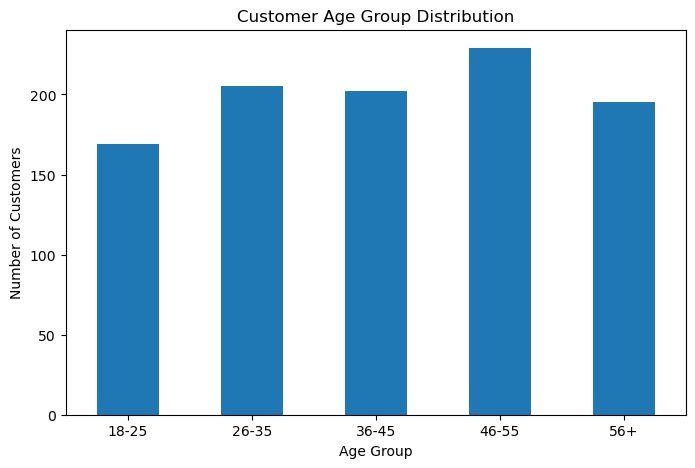

In [27]:
plt.figure(figsize=(8,5))
age_counts.plot(kind='bar')
plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [28]:
gender_counts=df['Gender'].value_counts()
print(gender_counts)

Gender
Female    510
Male      490
Name: count, dtype: int64


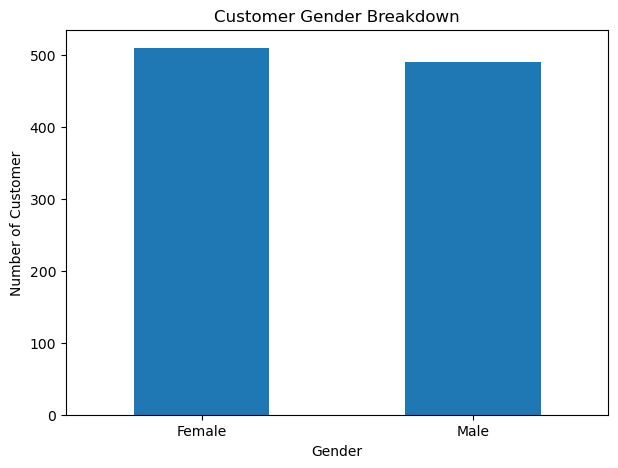

In [29]:
plt.figure(figsize=(7,5))
gender_counts.plot(kind='bar')
plt.title("Customer Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Customer")
plt.xticks(rotation=0)
plt.show()

# Product Analysis

In [32]:
top_10=(df.groupby("Product Category")['Quantity'].sum().sort_values(ascending=False).head(10))
print(top_10)
        

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


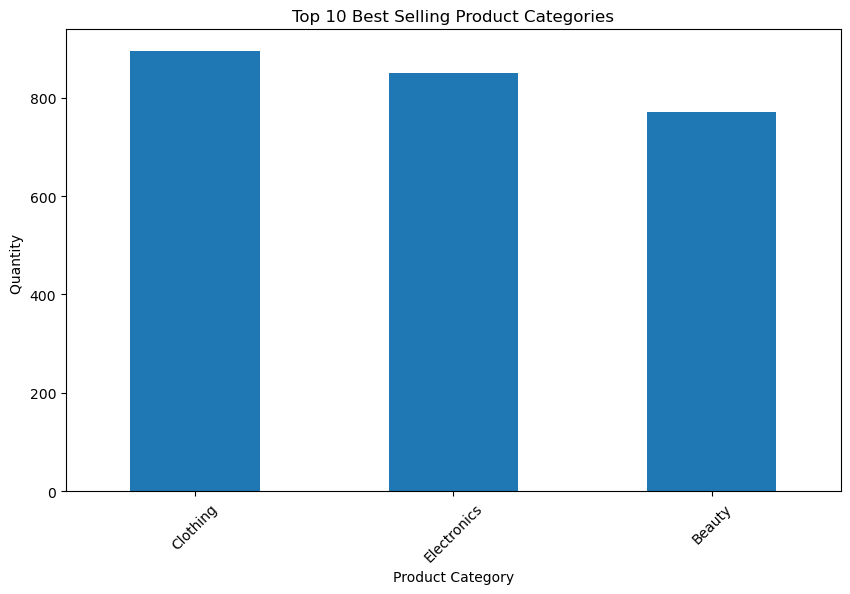

In [42]:
plt.figure(figsize=(10,6))
top_10.plot(kind="bar")
plt.title("Top 10 Best Selling Product Categories")
plt.xlabel('Product Category')
plt.ylabel("Quantity ")
plt.xticks(rotation=45)
plt.show()

In [45]:
category_revenue=(df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False))
print(category_revenue)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


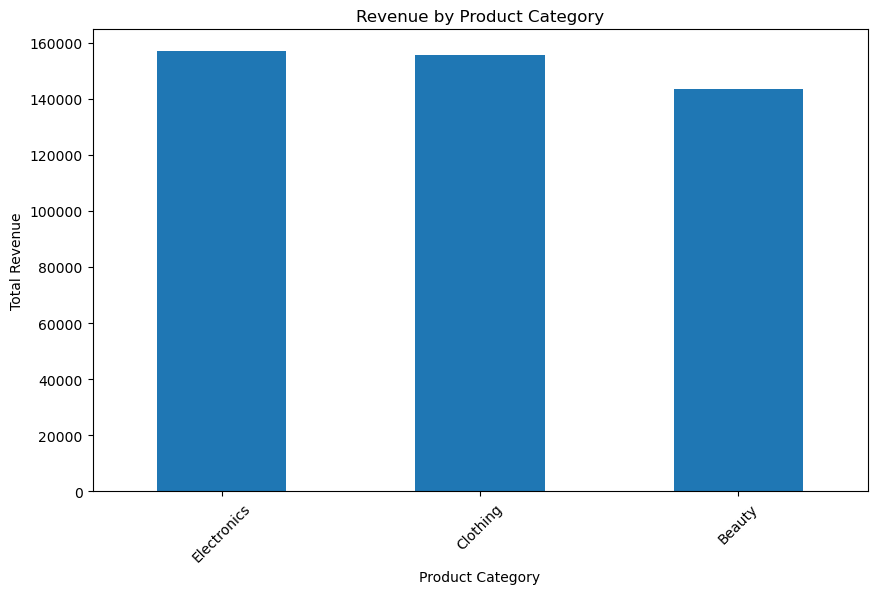

In [48]:
plt.figure(figsize=(10,6))
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap Matrix

In [52]:
import seaborn as sns

In [55]:
numeric_cols=df.select_dtypes(include="number")

correlation_matrix=numeric_cols.corr()
print(correlation_matrix)

                Transaction ID       Age  Quantity  Price per Unit  \
Transaction ID        1.000000  0.065191 -0.026623       -0.060837   
Age                   0.065191  1.000000 -0.023737       -0.038423   
Quantity             -0.026623 -0.023737  1.000000        0.017501   
Price per Unit       -0.060837 -0.038423  0.017501        1.000000   
Total Amount         -0.075034 -0.060568  0.373707        0.851925   
Sales                -0.075034 -0.060568  0.373707        0.851925   

                Total Amount     Sales  
Transaction ID     -0.075034 -0.075034  
Age                -0.060568 -0.060568  
Quantity            0.373707  0.373707  
Price per Unit      0.851925  0.851925  
Total Amount        1.000000  1.000000  
Sales               1.000000  1.000000  


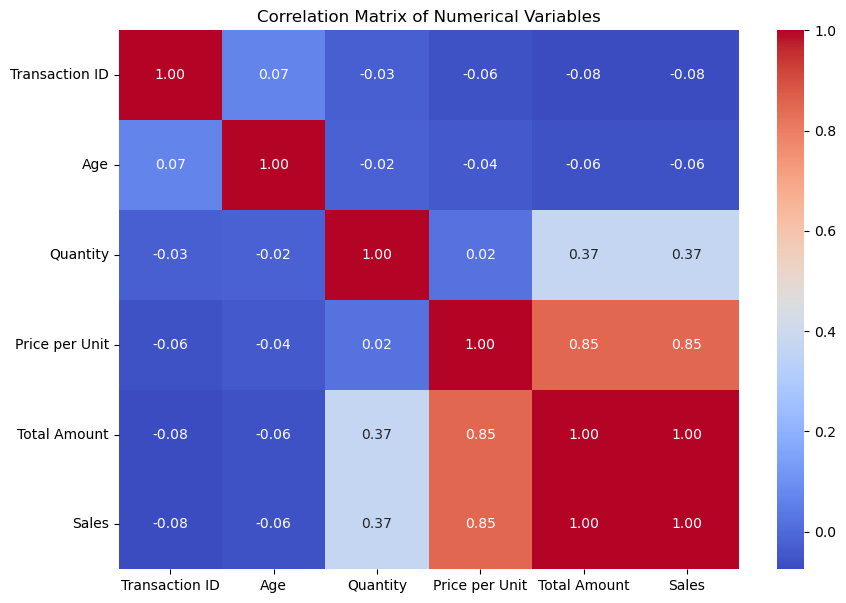

In [58]:
plt.figure(figsize=(10,7))
sns.heatmap(
    correlation_matrix,annot=True,cmap="coolwarm",fmt=".2f"
)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

# Additional Visualization - Age vs Spending

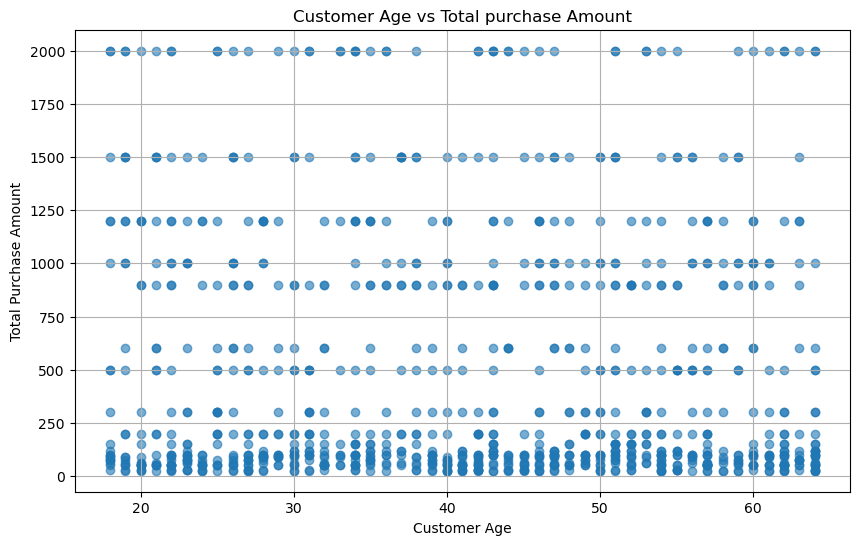

-0.060568023883045684


In [63]:
plt.figure(figsize=(10,6))
plt.scatter(df['Age'],df["Total Amount"],alpha=0.6)
plt.title("Customer Age vs Total purchase Amount")
plt.xlabel("Customer Age")
plt.ylabel("Total Purchase Amount")
plt.grid(True)
plt.show()
print(df['Age'].corr(df["Total Amount"]))